In [48]:
import logging, json
logging.basicConfig(format="%(asctime)s %(levelname)s - %(message)s", level=logging.INFO)

import pandas as pd
pd.set_option("display.min_rows", 4)
import numpy as np
import seaborn as sns
from tqdm import tqdm
from IPython.display import display, JSON

import matplotlib.pyplot as plt
%matplotlib inline

%reload_ext autoreload
%autoreload 2

from sapsam import parser, constants, filters 

# 1. CSV Format

The dataset is provided as a set of CSVs.

In [4]:
csv_paths = parser.get_csv_paths()

2026-08-02 21:47:58,887 INFO - Found 103 csvs


Let's parse the first rows of the first CSV.

In [5]:
csv_path = csv_paths[0]
print(csv_path.name)
df_raw = pd.read_csv(csv_path, nrows=5)
df_raw

0.csv


,Revision ID,Model ID,Organization ID,Datetime,Model JSON,Description,Name,Type,Namespace
0,5ed1535c95a342f4a414dd8c9b1b7df8,1ba74449e9354d0c9d4798b4a6e915d0,6c96d0b6e5e14eeaa9848f953a94e5f8,2019-03-19 11:36:50,"{""resourceId"": ""canvas"", ""properties"": {""name""...",NaN,Pivo,NaN,http://b3mn.org/stencilset/bpmn2.0#
1,301bfb5af53c431a830a6e435de6a590,1ba744cbcafb46c2a52482e36498a9bf,8af3fc1bb4b74e7c8c4089e4921d9056,2020-03-23 17:26:03,"{""resourceId"": ""canvas"", ""formats"": {""document...",NaN,Receipt of Application,NaN,http://b3mn.org/stencilset/bpmn2.0#
2,ac3baa3e59ca476396b4affa8e900c6f,1ba7587b3191422fb03a0e9ba92cebff,36fbc1ee23334e1ab987b07d2108eef2,2017-04-19 06:19:36,"{""resourceId"": ""canvas"", ""properties"": {""name""...",NaN,710 BPMN Conference room,NaN,http://b3mn.org/stencilset/bpmn2.0#
3,da11513a93224fbbb2c34ef9c5cfcaa9,1ba758f87e744ff0bcb3119887cac8cc,574093f96e5e4ff09a8b1f24eeb70284,2021-02-21 13:14:32,"{""resourceId"": ""canvas"", ""properties"": {""name""...",NaN,ECU application p,NaN,http://b3mn.org/stencilset/bpmn2.0#
4,70d06e82d8c344edab8b041f8b03161a,1ba77121c3be44d6bd0b354727f9707b,ff66cd6b779c44bba88ade8952d7e626,2020-06-30 07:12:48,"{""resourceId"": ""canvas"", ""properties"": {""name""...",NaN,2.9.1 Elektronischer Auftrag erfassen,NaN,http://b3mn.org/stencilset/bpmn2.0#


You can find a quick description of the columns in the `README.me` file of this repository.

Let's look at the model json format in more detail below.


In [6]:
model_json = json.loads(df_raw["Model JSON"][2])
print(model_json.keys())

dict_keys(['resourceId', 'properties', 'stencil', 'childShapes', 'bounds', 'stencilset', 'ssextensions', 'glossaryLinkRevisions'])


The root element of the model json represents the model itself.

In [7]:
print("Root id:", model_json["resourceId"])
print("Root type:", model_json["stencil"]["id"])

Root id: canvas
Root type: BPMNDiagram


The most important part is the childShapes list. The childShapes is a recursive structure that can contain additional childShapes. For example, the elements of a pool are typically tracked as childShapes of the corresponding pool.

In [8]:
from collections import defaultdict
from typing import Dict

def get_child_elements_by_category(element) -> Dict:
    cat_to_elements = defaultdict(list)
    for child in element["childShapes"]:
        category = child["stencil"]["id"]
        cat_to_elements[category].append(child)
    
    cat = element["stencil"]["id"]
    print("{} children category count: {}".format(cat, {k: len(v) for k,v in cat_to_elements.items()}))
    return cat_to_elements

root_child_dict = get_child_elements_by_category(model_json)

BPMNDiagram children category count: {'Pool': 1, 'SequenceFlow': 17}


Let's check out the first pool:

In [9]:
pool = root_child_dict["Pool"][0]
pool_child_dict = get_child_elements_by_category(pool)

Pool children category count: {'Lane': 3}


Now let's see which children each lane has:

In [10]:
for lane in pool_child_dict["Lane"]:
    get_child_elements_by_category(lane)

Lane children category count: {'Task': 2}
Lane children category count: {'Task': 8, 'Exclusive_Databased_Gateway': 2, 'EndNoneEvent': 1}
Lane children category count: {'StartNoneEvent': 1, 'Task': 2, 'EndNoneEvent': 1}


Let's look at the properties of the first lane element in more detail:

In [11]:
lane = pool_child_dict["Lane"][0]
shape = lane["childShapes"][0]
shape

{'resourceId': 'sid-652AF256-318D-40D9-9E1D-93877996929C',
 'properties': {'processid': '',
  'name': 'Inventory and Food Required',
  'documentation': '',
  'auditing': '',
  'monitoring': '',
  'flat': '',
  'categories': '',
  'startquantity': 1,
  'completionquantity': 1,
  'isforcompensation': False,
  'assignments': '',
  'callacitivity': False,
  'tasktype': 'None',
  'implementation': 'webService',
  'resources': '',
  'messageref': '',
  'operationref': '',
  'instantiate': False,
  'script': '',
  'scriptformat': '',
  'bgcolor': '#ffffcc',
  'looptype': 'None',
  'testbefore': False,
  'loopcondition': '',
  'loopmaximum': '',
  'loopcardinality': '',
  'loopdatainput': '',
  'loopdataoutput': '',
  'inputdataitem': '',
  'outputdataitem': '',
  'behavior': 'all',
  'complexbehaviordefinition': '',
  'completioncondition': '',
  'onebehavioreventref:': 'signal',
  'nonebehavioreventref': 'signal',
  'properties': '',
  'properties2': '',
  'datainputs': '',
  'dataoutputs': 

As can be seen, each shape has a lot of attributes, most of which are irrelevant for common use cases. Let us summarize the most important attributes:

In [12]:
print("Shape id:", shape["resourceId"])
print("Shape type:", shape["stencil"]["id"])
print("Label:", shape["properties"]["name"].replace("\n", "\\n"))
print("Bounding box:", shape["bounds"])
print("Outgoing:", shape["outgoing"])
print("Parent element:", lane["resourceId"])

Shape id: sid-652AF256-318D-40D9-9E1D-93877996929C
Shape type: Task
Label: Inventory and Food Required
Bounding box: {'lowerRight': {'x': 714, 'y': 116}, 'upperLeft': {'x': 614, 'y': 36}}
Outgoing: [{'resourceId': 'sid-D8501DB4-4B74-42B6-A91B-1E8F3862FACF'}]
Parent element: sid-A7ACCB17-82C8-4314-A762-F46070C31996


Parsing all the raw CSVs into one DataFrame uses a lot of memory and is rather slow. As the model json contains many attributes that are irrelevant for most uses cases, we provide a parser that only extracts the elements mentioned before, and returns a DataFrame with a row per model element. The parser only considers BPMN models, and can be used as a starting point to also develop parsers for other diagram types.

We showcase the parser in the BPMN Model Elements section.

# 2. Model Metadata

Parsing the entire CSV with the "Model JSON" attribute consumes a lot of memory and is rather slow. We therefore provide a parser that ignores the "Model JSON" field and only parses the remaining model metadata columns. We also lower the column names and convert them to snake_case to make it more convenient to work with them in Pandas.

In [13]:
df_meta = parser.parse_model_metadata()
df_meta

2026-08-02 21:47:59,991 INFO - Found 103 csvs
2026-08-02 21:47:59,992 INFO - Starting to parse 103 csv excluding model json
100%|██████████| 103/103 [01:56<00:00,  1.13s/it]
2026-08-02 21:49:56,528 INFO - Parsed 1021471 models


,revision_id,organization_id,datetime,description,name,type,namespace
model_id,,,,,,,
1ba74449e9354d0c9d4798b4a6e915d0,5ed1535c95a342f4a414dd8c9b1b7df8,6c96d0b6e5e14eeaa9848f953a94e5f8,2019-03-19 11:36:50,NaN,Pivo,NaN,http://b3mn.org/stencilset/bpmn2.0#
1ba744cbcafb46c2a52482e36498a9bf,301bfb5af53c431a830a6e435de6a590,8af3fc1bb4b74e7c8c4089e4921d9056,2020-03-23 17:26:03,NaN,Receipt of Application,NaN,http://b3mn.org/stencilset/bpmn2.0#
...,...,...,...,...,...,...,...
18ca2c45cb824d06ae8573f0afb8813e,ace1037ddbbf4e91b03d60c0b6cf9162,359f2e98c56444b287a7818dc1a531b2,2018-01-13 12:23:47,NaN,2,NaN,http://b3mn.org/stencilset/bpmn2.0#
18ca2e80f3ff41a3a00dbce414c06506,8811500ae44f45e1befdcbd7b92e86da,096354c3fa3e4ec4a54a1b5297b46bc6,2018-12-01 18:17:11,NaN,Gyártáshoz szükséges cikk lekérdezése,NaN,http://b3mn.org/stencilset/epc#


The df_meta dataframe can be used to perform analysis on model level, e.g. to analyze the frequency of each modeling notation or to analyze the model names.

Here is an example that shows the distribution of the length of the model names:

,count,mean,std,min,25%,50%,75%,max
name,1021471.0,23.3,12.17,1.0,15.0,21.0,29.0,273.0


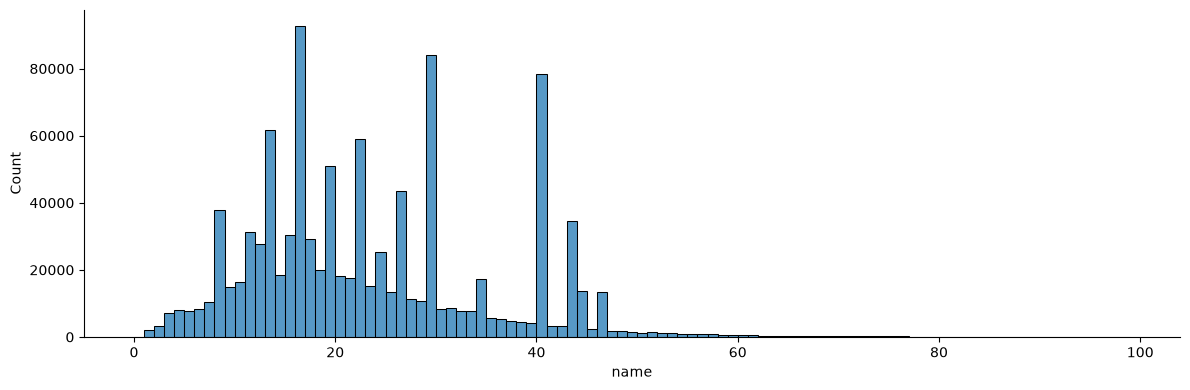

In [14]:
s_name_len = df_meta.name.map(lambda o: len(str(o)))
sns.displot(s_name_len, bins=np.arange(100), height=4, aspect=3);
s_name_len.describe().to_frame().T.round(2)

The sharp peaks might stem from the example processes that are added to each newly created workspace and might be worth further investigation. :-)

# 3. BPMN Model Elements

As mentioned, we provide a BPMN model parser that returns a DataFrame with one row per model element.

In [15]:
p = parser.BpmnModelParser()
df = p.parse_model_elements()
df.head()

2026-08-02 21:49:57,565 INFO - Found 103 csvs
2026-08-02 21:49:57,565 INFO - Starting to parse 103 csv
100%|██████████| 103/103 [14:31<00:00,  8.46s/it]


category  \
model_id                         element_id                                                    
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD        MessageFlow   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE               Pool   
                                 sid-3E27602D-0560-44E1-8089-4FC264FA9803               Lane   
                                 sid-6E3EE415-179F-4D56-AA73-B8D0CC2B5246  StartMessageEvent   
                                 sid-ED915395-D5F6-44D6-80C5-11D279EBC262       SequenceFlow   

                                                                                          label  \
model_id                         element_id                                                       
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD                         
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE             Konobar\n   
                                 sid-3E27602D-0560-44E1-8089-4FC264FA9803                         
                                 sid-6E3EE415-179F-4D56-AA73-B8D0CC2B5246  Narudžba primljena\n   
                                 sid-ED915395-D5F6-44D6-80C5-11D279EBC262                         

                                                                          glossary_link_id  \
model_id                         element_id                                                  
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD             None   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE             None   
                                 sid-3E27602D-0560-44E1-8089-4FC264FA9803             None   
                                 sid-6E3EE415-179F-4D56-AA73-B8D0CC2B5246             None   
                                 sid-ED915395-D5F6-44D6-80C5-11D279EBC262             None   

                                                                           name  
model_id                         element_id                                      
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD  Pivo  
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE  Pivo  
                                 sid-3E27602D-0560-44E1-8089-4FC264FA9803  Pivo  
                                 sid-6E3EE415-179F-4D56-AA73-B8D0CC2B5246  Pivo  
                                 sid-ED915395-D5F6-44D6-80C5-11D279EBC262  Pivo

Let's cache the DataFrame as a pickle file.

In [16]:
df.to_pickle(constants.DATA_INTERIM / "bpmn_elements.pkl")

In other notebooks/code, this dataframe can then directly loaded with the reverse operation:

df = pd.read_pickle(constants.DATA_INTERIM / "bpmn_elements.pkl")

## 3.1 BPMN constructs

We can group by `model_id` and then count the number of time each element type appears per model:

In [17]:
df_cnts = (
    df.groupby("model_id").category
    .value_counts()
    .to_frame("count")
    .unstack()
    .droplevel(0, axis='columns') # drop first level column level "count" that unstack produces
    .fillna(0, downcast="infer")
)
df_cnts

C:\Users\yousu\AppData\Local\Temp\ipykernel_11944\1410899951.py:7: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  .fillna(0, downcast="infer")


category,Association_Bidirectional,Association_Undirected,Association_Unidirectional,ChoreographyParticipant,ChoreographyTask,CollapsedEventSubprocess,CollapsedPool,CollapsedSubprocess,CollapsedVerticalPool,Communication,...,TextAnnotation,VerticalLane,VerticalPool,gdashedline,gdiamond,gdottedline,gellipse,grect,gtext,processparticipant
model_id,,,,,,,,,,,,,,,,,,,,,
0000150e890c45928d26584d491ada68,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00001f477e9a4fb1b9dcb27e029a426d,0,2,3,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffff2b0eafa4ecca0b00fb5c6ccb4ef,0,2,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
ffffffd24864440a8effa3cdb9d37cce,0,8,2,0,0,0,1,2,0,0,...,0,0,0,0,0,0,0,0,0,0


Plot how often each element type appears in a model at least once:

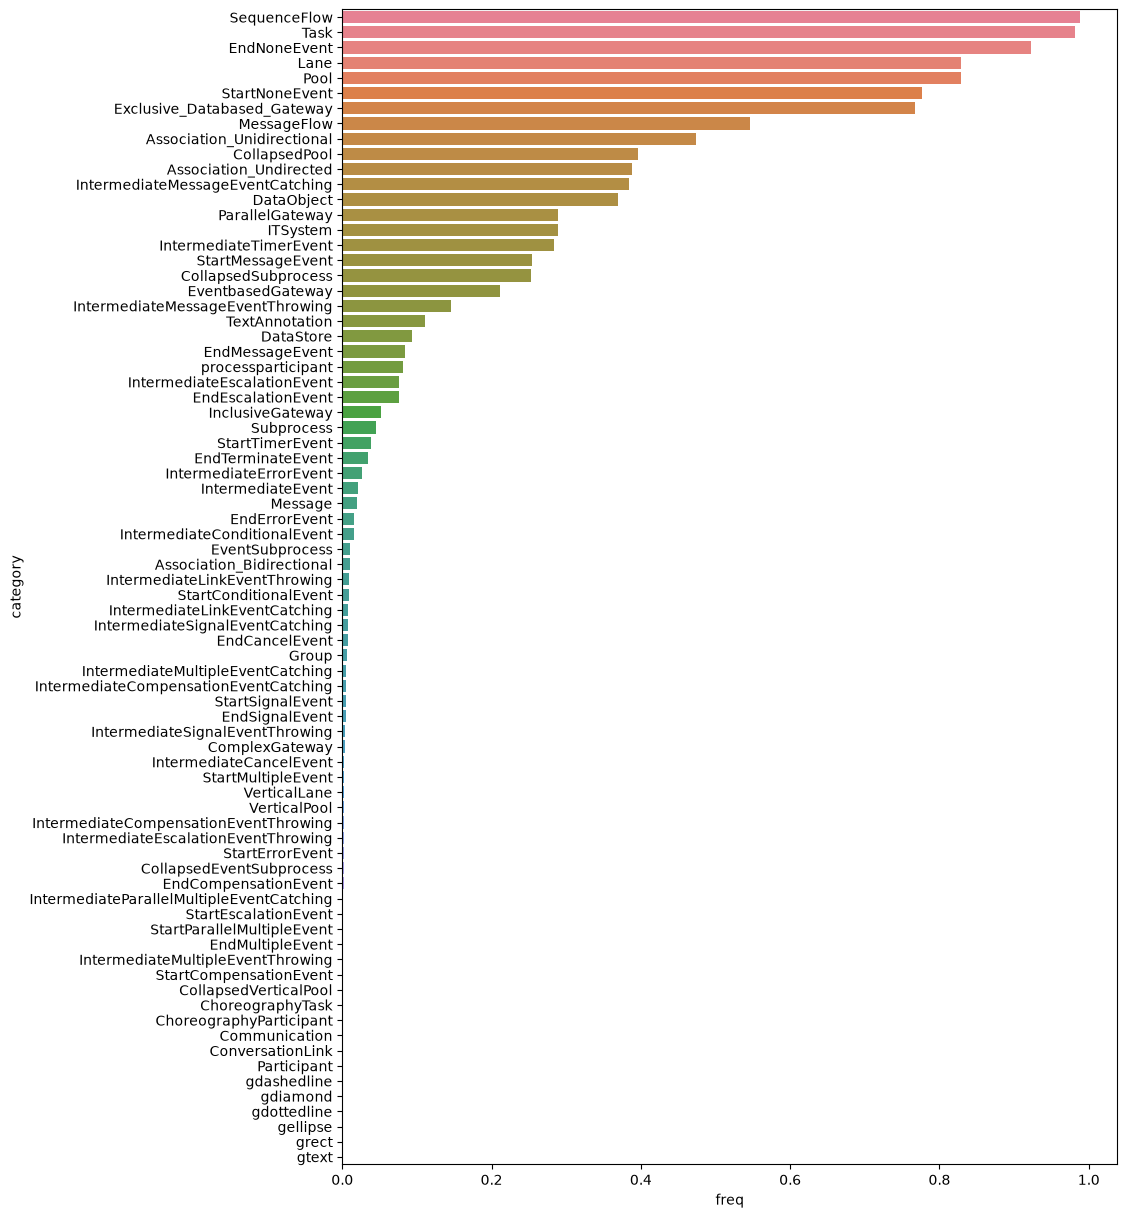

In [18]:
df_freq = (
    df_cnts
    .gt(0)
    .sum()
    .div(len(df_cnts))
    .sort_values(ascending=False)
    .to_frame("freq")
    .reset_index()
)

plt.figure(figsize=(10, 15))

sns.barplot(
    data=df_freq,
    x="freq",
    y="category",
    hue="category",
    palette="husl",
    dodge=False,
    legend=False
)

plt.show()

## 3.2 BPMN labels

We can also analyze the labels of the model elements. Let's compute the length of each label:

In [19]:
df_lbl_len = df.label.fillna("").map(len).to_frame("lbl_len")
df_lbl_len

lbl_len
model_id                         element_id                                       
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD        0
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE        8
...                                                                            ...
18ca2c45cb824d06ae8573f0afb8813e sid-95E44D63-A1AA-46F8-966E-E28F326ED50A       15
                                 sid-6B8FC9F7-9A29-43F2-BE0B-D494F6275B8F       27

[28293762 rows x 1 columns]

Now let's check the maximum label length per model:

,count,mean,std,min,25%,50%,75%,max
lbl_len,605506.0,41.3,30.3,0.0,33.0,40.0,44.0,4043.0


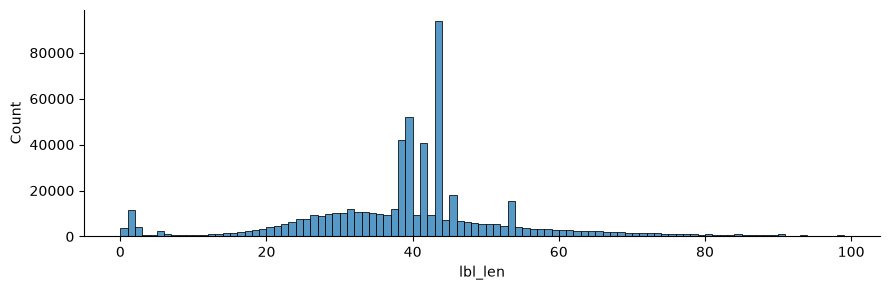

In [20]:
df_lbl_max_len = df_lbl_len.groupby("model_id").lbl_len.max()
sns.displot(df_lbl_max_len, bins=np.arange(100), height=3, aspect=3);
df_lbl_max_len.describe().to_frame().T.round(1)

Again, the peaks around 40 might stem from the high number of example processes present in the dataset.

## 3.3 BPMN relations

The outgoing and parent attributes can be used to analyze the edges in the BPMN models and also hierarchical relations, such as how many elements a lane typically contains. The `BpmnModelParser` has two parameters that can be used to parse these attributes. As the resulting DataFrame for the entire dataset would consume a lot of memory, we only show the result when parsing the first CSV:

In [21]:
rel_parser = parser.BpmnModelParser(parse_outgoing=True, parse_parent=True)
df_rel = rel_parser.parse_model_elements(csv_paths=csv_paths[:1])
df_rel

2026-08-02 22:08:32,043 INFO - Starting to parse 1 csv
100%|██████████| 1/1 [00:09<00:00,  9.30s/it]


category  \
model_id                         element_id                                                 
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD     MessageFlow   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE            Pool   
...                                                                                   ...   
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD            Task   
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF  StartNoneEvent   

                                                                                      label  \
model_id                         element_id                                                   
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD                     
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE         Konobar\n   
...                                                                                     ...   
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD    GREET AND SEAT   
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF  CUSTOMER ARRIVED   

                                                                          glossary_link_id  \
model_id                         element_id                                                  
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD             None   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE             None   
...                                                                                    ...   
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD             None   
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF             None   

                                                                           parent  \
model_id                         element_id                                         
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD  canvas   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE  canvas   
...                                                                           ...   
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD  canvas   
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF  canvas   

                                                                                                             outgoing  \
model_id                         element_id                                                                             
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD  [sid-6E3EE415-179F-4D56-AA73-B8D0CC2B5246]   
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE                                          []   
...                                                                                                               ...   
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD  [sid-75E11EA7-60E0-4C6E-919A-F1C511E61AD9]   
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF  [sid-0AC8122D-1CFF-4777-B186-D2273EA8EF3D]   

                                                                                        name  
model_id                         element_id                                                   
1ba74449e9354d0c9d4798b4a6e915d0 sid-7D3363B0-6AAD-4B13-AFAD-B3F2525191FD               Pivo  
                                 sid-00A06776-842A-40B5-9F67-A7A2B247CBAE               Pivo  
...                                                                                      ...  
1e29cf037dde455f8cd83ebf1aa15cb9 sid-CD5BA5A2-D5AA-415E-818A-E934A4E2FFAD  W1-P1(NGWENGKHEI)  
                                 sid-626AA700-9D69-4045-88A0-AB3FBECAB0BF  W1-P1(NGWENGKHE

In [22]:
print("Total models (all notations):", len(df_meta))

df_bpmn_meta = df_meta[df_meta["namespace"] == constants.BPMN2_NAMESPACE]
print("Raw BPMN 2.0 models (incl. duplicate revisions):", len(df_bpmn_meta))

Total models (all notations): 1021471
Raw BPMN 2.0 models (incl. duplicate revisions): 618807


In [23]:
df_bpmn_meta_sorted = df_bpmn_meta.sort_values("datetime")
df_bpmn_meta_latest = df_bpmn_meta_sorted[~df_bpmn_meta_sorted.index.duplicated(keep="last")]
print("Unique BPMN 2.0 models (latest revision only):", len(df_bpmn_meta_latest))

Unique BPMN 2.0 models (latest revision only): 618807


In [24]:
p = parser.BpmnModelParser()
df = p.parse_model_elements()
print("Elements parsed:", len(df))

valid_ids = df_bpmn_meta_latest.index
df = df[df.index.get_level_values("model_id").isin(valid_ids)]
print("Unique models after dedupe applied to element table:", df.index.get_level_values("model_id").nunique())

df.to_pickle(constants.DATA_INTERIM / "bpmn_elements.pkl")

2026-08-02 22:47:09,511 INFO - Found 103 csvs
2026-08-02 22:47:09,512 INFO - Starting to parse 103 csv
100%|██████████| 103/103 [23:36<00:00, 13.75s/it]


Elements parsed: 28293762
Unique models after dedupe applied to element table: 605506


In [27]:
df = pd.read_pickle(constants.DATA_INTERIM / "bpmn_elements.pkl")
df = filters.filter_example_processes_bpmn(df)

Filtering out example processes models...
Keeping 390975 out of 605506 from the dataset
Dataset has been filtered down to 390975 models, a decrease of 35.43%.



In [28]:
MIN_ELEMENTS = 5  # adjust threshold as you like

df = filters.filter_models(df, value=MIN_ELEMENTS)

Filtering out models with less than 5 elements...
Keeping 386377 out of 390975 from the dataset
Filtering out models with no start, end, or task elements...
Keeping 357373 out of 386377 from the dataset

Dataset has been filtered down to 357373 models, a decrease of 8.59%.


In [33]:
from sapsam.detector import ModelLanguageDetector

detector = ModelLanguageDetector(threshold=0.9)  # threshold currently unused inside class but kept for future confidence filtering

df_labels = detector.get_detected_natural_language_from_bpmn_model(df)
df_labels

100%|██████████| 357373/357373 [1:11:16<00:00, 83.56it/s] 


,label,name,detected_natural_language
model_id,,,
0000150e890c45928d26584d491ada68,CredibilityAssessment IN {rejected}\n Checked...,P5,en
00003a67300748639e4bc21398bb5ede,,Test process,UNKNOWN
...,...,...,...
ffffe3bf630542ef846c139be1af7469,si no FAST CONNECTION UFFICIO PEDAGGI ADDEBIT...,FastConnection ES6,it
ffffffd24864440a8effa3cdb9d37cce,ja nein Ja Finetech GmbH Team Lead Sales Euro...,Angebotserstellung Markt Europa,de


In [34]:
lang_counts = df_labels["detected_natural_language"].value_counts()
print(lang_counts)

df_english = df_labels[df_labels["detected_natural_language"] == "en"]
print("Valid, English-language BPMN 2.0 models:", len(df_english))

detected_natural_language
en         175514
de          93740
it          18257
es          16046
fr           8168
hr           7999
pt           6046
nl           4500
et           4381
sl           3886
ro           3211
id           2755
sv           2112
hu           1396
pl           1386
el           1383
UNKNOWN      1337
da            500
no            448
ca            434
fi            381
vi            368
tr            366
cy            366
af            359
ja            283
cs            254
lv            245
zh-cn         190
sk            169
so            155
sq            153
ru            144
tl            140
ko             86
mk             78
lt             70
fa             36
sw             23
ar              4
th              2
uk              1
bg              1
Name: count, dtype: int64
Valid, English-language BPMN 2.0 models: 175514


In [35]:
print(f"""
Funnel:
  Raw BPMN 2.0 rows (all revisions): {len(df_bpmn_meta)}
  Unique models (latest revision):   {len(df_bpmn_meta_latest)}
  After removing example processes + invalid models: {df.index.get_level_values('model_id').nunique() if 'model_id' in df.index.names else 'n/a'}
  Final English-only valid models:   {len(df_english)}
""")


Funnel:
  Raw BPMN 2.0 rows (all revisions): 618807
  Unique models (latest revision):   618807
  After removing example processes + invalid models: 357373
  Final English-only valid models:   175514



## 4. Data Transformation 

In [36]:
valid_model_ids = set(df_english.index.astype(str))
print(f"Fetching raw rows for {len(valid_model_ids)} valid models...")

raw_rows = []
for csv_path in csv_paths:
    df_chunk = pd.read_csv(
        csv_path,
        usecols=["Revision ID", "Model ID", "Organization ID", "Datetime", "Model JSON", "Description", "Name"],
        dtype=str,
    )
    df_chunk = df_chunk[df_chunk["Model ID"].isin(valid_model_ids)]
    if not df_chunk.empty:
        raw_rows.append(df_chunk)

df_raw_valid = pd.concat(raw_rows, ignore_index=True)
df_raw_valid = df_raw_valid.drop_duplicates(subset="Model ID", keep="last")
print(f"Raw rows fetched: {len(df_raw_valid)}")

Fetching raw rows for 175514 valid models...
Raw rows fetched: 175514


In [37]:
class ConnectivityResolutionError(Exception):
    pass


def _walk_shapes(shapes):
    for shape in shapes or []:
        stencil = (shape.get("stencil") or {}).get("id", "")
        yield shape.get("resourceId"), stencil, shape
        yield from _walk_shapes(shape.get("childShapes"))


def _build_registries(model: dict):
    shapes, flows = {}, {}
    for rid, stencil, shape in _walk_shapes(model.get("childShapes")):
        if rid is None:
            continue
        props = shape.get("properties") or {}
        name = (props.get("name") or "").strip()
        outgoing = [o.get("resourceId") for o in shape.get("outgoing", [])]

        if stencil == "Task":
            shapes[rid] = {"type": "Task", "stencil": stencil, "name": name, "properties": props, "outgoing": outgoing}
        elif "Gateway" in stencil:
            shapes[rid] = {"type": "Gateway", "stencil": stencil, "name": name, "properties": props, "outgoing": outgoing}
        elif stencil.startswith("Start"):
            shapes[rid] = {"type": "StartEvent", "stencil": stencil, "name": name, "properties": props, "outgoing": outgoing}
        elif stencil.startswith("End"):
            shapes[rid] = {"type": "EndEvent", "stencil": stencil, "name": name, "properties": props, "outgoing": outgoing}
        elif "Event" in stencil:
            shapes[rid] = {"type": "IntermediateEvent", "stencil": stencil, "name": name, "properties": props, "outgoing": outgoing}
        elif stencil == "SequenceFlow":
            flows[rid] = {"name": name, "target": (shape.get("target") or {}).get("resourceId")}

    return shapes, flows


def _classify_gateway_type(shape: dict) -> str:
    gt = (shape.get("properties") or {}).get("gatewaytype", "").upper()
    if gt == "XOR":
        return "EXCLUSIVE"
    if gt == "AND":
        return "PARALLEL"
    if gt == "OR":
        return "INCLUSIVE"
    stencil = shape.get("stencil", "")
    if "Exclusive" in stencil:
        return "EXCLUSIVE"
    if "Parallel" in stencil:
        return "PARALLEL"
    if "Inclusive" in stencil:
        return "INCLUSIVE"
    if "Eventbased" in stencil or "EventBased" in stencil:
        return "EVENT_BASED"
    return "EXCLUSIVE"


def resolve_connectivity(model: dict) -> dict:
    shapes, flows = _build_registries(model)

    def outgoing_edges(shape_id):
        shape = shapes.get(shape_id)
        if shape is None:
            return []
        return [(flows[f]["target"], flows[f].get("name") or "")
                for f in shape.get("outgoing", []) if f in flows and flows[f].get("target")]

    split_gateways, pass_through = set(), set()
    for shape_id, shape in shapes.items():
        if shape["type"] == "Gateway":
            (split_gateways if len(outgoing_edges(shape_id)) > 1 else pass_through).add(shape_id)
        elif shape["type"] == "IntermediateEvent":
            pass_through.add(shape_id)

    def skip_pass_through(shape_id, max_hops=30):
        current, hops = shape_id, 0
        while current in pass_through and hops < max_hops:
            edges = outgoing_edges(current)
            if not edges:
                return current
            current, _ = edges[0]
            hops += 1
        if hops >= max_hops:
            raise ConnectivityResolutionError(f"Pass-through chain from {shape_id} exceeded max hops (cycle?).")
        return current

    def classify(shape_id):
        real_id = skip_pass_through(shape_id)
        shape = shapes.get(real_id)
        if shape is None:
            raise ConnectivityResolutionError(f"Unresolvable shape reference: {real_id}")
        if shape["type"] == "Task":
            return ("task", real_id)
        if shape["type"] == "Gateway" and real_id in split_gateways:
            return ("gateway", real_id)
        if shape["type"] == "EndEvent":
            return ("end", shape.get("name") or "End")
        if real_id in pass_through:
            return ("end", "End")
        raise ConnectivityResolutionError(f"Shape {real_id} ({shape['type']}) is not a valid flow destination.")

    task_next = {}
    for shape_id, shape in shapes.items():
        if shape["type"] != "Task":
            continue
        edges = outgoing_edges(shape_id)
        task_next[shape_id] = ("end", "End") if not edges else classify(edges[0][0])

    gateway_branches = {
        gw_id: [{"label": label, **dict(zip(("kind", "target"), classify(target)))}
                for target, label in outgoing_edges(gw_id)]
        for gw_id in split_gateways
    }

    gateway_predecessor = {gw_id: None for gw_id in split_gateways}
    for shape_id, (kind, target) in task_next.items():
        if kind == "gateway":
            gateway_predecessor[target] = ("task", shape_id)
    for gw_id, branches in gateway_branches.items():
        for b in branches:
            if b["kind"] == "gateway":
                gateway_predecessor[b["target"]] = ("gateway", gw_id)

    def reachable_task_count(ref):
        seen, count = set(), 0

        def visit(node_ref):
            nonlocal count
            kind, ident = node_ref
            if kind == "end" or (kind, ident) in seen:
                return
            seen.add((kind, ident))
            if kind == "task":
                count += 1
                visit(task_next[ident])
            elif kind == "gateway":
                for b in gateway_branches[ident]:
                    if b["kind"] in ("task", "gateway"):
                        visit((b["kind"], b["target"]))

        visit(ref)
        return count

    start_events = [sid for sid, s in shapes.items() if s["type"] == "StartEvent"]
    if not start_events:
        raise ConnectivityResolutionError("No StartEvent found in diagram.")

    start_ref, best_count = None, -1
    for se in start_events:
        edges = outgoing_edges(se)
        if not edges:
            continue
        candidate = classify(edges[0][0])
        if candidate[0] == "end":
            continue
        count = reachable_task_count(candidate)
        if count > best_count:
            start_ref, best_count = candidate, count

    if start_ref is None:
        raise ConnectivityResolutionError("No StartEvent leads to any task.")

    def forward_sequence(ref, max_len=200):
        seq, seen = [], set()
        kind, ident = ref
        while len(seq) < max_len and (kind, ident) not in seen:
            seen.add((kind, ident))
            seq.append((kind, ident))
            if kind == "end":
                break
            if kind == "task":
                kind, ident = task_next[ident]
            else:
                break
        return seq

    gateway_convergence = {}
    for gw_id in split_gateways:
        gtype = _classify_gateway_type(shapes[gw_id])
        if gtype not in ("PARALLEL", "INCLUSIVE"):
            continue
        sequences = [forward_sequence((b["kind"], b["target"])) for b in gateway_branches[gw_id]]
        common = next((node for node in sequences[0] if all(node in s for s in sequences[1:])), None)
        if common is None:
            name = shapes[gw_id].get("name") or gw_id
            raise ConnectivityResolutionError(f"No common convergence point found for gateway '{name}'.")
        gateway_convergence[gw_id] = common

    return {
        "shapes": shapes,
        "split_gateways": split_gateways,
        "gateway_type_of": {gw_id: _classify_gateway_type(shapes[gw_id]) for gw_id in split_gateways},
        "start_ref": start_ref,
        "task_next": task_next,
        "gateway_predecessor": gateway_predecessor,
        "gateway_branches": gateway_branches,
        "gateway_convergence": gateway_convergence,
    }


def build_ordered_task_list(resolved: dict):
    order, seen = [], set()
    reachable_gateways = set()

    def visit(ref):
        kind, ident = ref
        if kind == "end" or (kind, ident) in seen:
            return
        seen.add((kind, ident))
        if kind == "task":
            order.append(ident)
            visit(resolved["task_next"][ident])
        elif kind == "gateway":
            reachable_gateways.add(ident)
            for b in resolved["gateway_branches"][ident]:
                if b["kind"] in ("task", "gateway"):
                    visit((b["kind"], b["target"]))

    visit(resolved["start_ref"])
    return order, reachable_gateways

In [38]:
CONTROL_KEYWORDS = ("check", "verify", "validate", "inspect", "review", "audit", "confirm")
AUTHORIZE_KEYWORDS = ("approve", "authorize", "sign off", "sign-off", "accept", "reject")
COMMUNICATION_KEYWORDS = ("send", "notify", "inform", "contact", "call", "email", "receive", "request", "reply")
BATCH_KEYWORDS = ("batch", "consolidate", "aggregate", "compile")
PERIODIC_KEYWORDS = ("end of day", "eod", "daily", "weekly", "monthly", "periodic", "end of month")
VA_KEYWORDS = ("create", "prepare", "produce", "build", "design", "develop", "generate")


def classify_activity_type(name: str) -> str:
    lower = name.lower()
    if any(k in lower for k in COMMUNICATION_KEYWORDS):
        return "communication"
    if any(k in lower for k in CONTROL_KEYWORDS):
        return "check"
    if any(k in lower for k in AUTHORIZE_KEYWORDS):
        return "authorize"
    if any(k in lower for k in BATCH_KEYWORDS):
        return "batch"
    return "basic"


def classify_value(name: str, activity_type: str) -> str:
    lower = name.lower()
    if activity_type in ("check", "authorize"):
        return "BVA"
    if any(k in lower for k in VA_KEYWORDS):
        return "VA"
    return "BVA"


def is_periodic(name: str) -> bool:
    return any(k in name.lower() for k in PERIODIC_KEYWORDS)


def is_batch(name: str, activity_type: str) -> bool:
    return activity_type == "batch"


def derive(name: str) -> dict:
    activity_type = classify_activity_type(name)
    return {
        "activity_type": activity_type,
        "value_classification": classify_value(name, activity_type),
        "is_periodic": is_periodic(name),
        "is_batch": is_batch(name, activity_type),
    }

In [39]:
import xml.etree.ElementTree as ET
import random

DEFAULT_JOB_TITLES = ("Process Owner", "Department Manager", "Analyst", "Coordinator",
                      "Specialist", "Clerk", "Supervisor")

SYNTH_SEED = 7
HOURLY_RATE_RANGE = (15, 120)
PROCESS_TIME_RANGE_MIN = (5, 240)
REWORK_TIME_FRACTION_RANGE = (0.05, 0.25)
DEFAULT_CURRENCY = "USD"


def _synth_job(rng: random.Random, job_id: int) -> dict:
    title = rng.choice(DEFAULT_JOB_TITLES)
    return {
        "job_id": job_id, "jobCode": f"SYN-J-{job_id}", "job_level_id": rng.randint(1, 6),
        "hourlyRate": rng.randint(*HOURLY_RATE_RANGE), "maxHoursPerDay": 8,
        "description": f"Synthetic role: {title}", "name": title,
        "capacity_buffer": str(rng.choice([5, 10, 15, 20])), "days_per_week": "5",
        "hours_per_day": "8", "currencyType": DEFAULT_CURRENCY,
    }


def _build_bpmn_xml(resolved: dict, process_name: str, process_code: str) -> str:
    ns = "http://www.omg.org/spec/BPMN/20100524/MODEL"
    ET.register_namespace("bpmn", ns)
    definitions = ET.Element(f"{{{ns}}}definitions", {
        "id": f"Definitions_{process_code}", "targetNamespace": "http://synthetic.local/bpmn",
    })
    process_el = ET.SubElement(definitions, f"{{{ns}}}process", {
        "id": f"Process_{process_code}", "name": process_name, "isExecutable": "false",
    })
    for rid, shape in resolved["shapes"].items():
        if shape["type"] == "Task":
            ET.SubElement(process_el, f"{{{ns}}}task", {"id": rid, "name": shape["name"]})
        elif shape["type"] in ("StartEvent", "EndEvent"):
            tag = "startEvent" if shape["type"] == "StartEvent" else "endEvent"
            ET.SubElement(process_el, f"{{{ns}}}{tag}", {"id": rid, "name": shape["name"]})
    for gw_id in resolved["split_gateways"]:
        gtype = resolved["gateway_type_of"][gw_id]
        tag = {"EXCLUSIVE": "exclusiveGateway", "PARALLEL": "parallelGateway",
               "INCLUSIVE": "inclusiveGateway", "EVENT_BASED": "eventBasedGateway"}[gtype]
        ET.SubElement(process_el, f"{{{ns}}}{tag}", {"id": gw_id, "name": resolved["shapes"][gw_id]["name"]})

    # --- fix: emit sequenceFlow elements so the graph actually has edges ---
    flow_idx = 0
    for rid, shape in resolved["shapes"].items():
        if shape["type"] == "Task":
            nxt = resolved["task_next"].get(rid)
            if nxt and nxt[0] in ("task", "gateway"):
                flow_idx += 1
                ET.SubElement(process_el, f"{{{ns}}}sequenceFlow",
                              {"id": f"Flow_{flow_idx}", "sourceRef": rid, "targetRef": nxt[1]})
    for gw_id in resolved["split_gateways"]:
        for b in resolved["gateway_branches"][gw_id]:
            if b["kind"] in ("task", "gateway"):
                flow_idx += 1
                ET.SubElement(process_el, f"{{{ns}}}sequenceFlow",
                              {"id": f"Flow_{flow_idx}", "sourceRef": gw_id, "targetRef": b["target"]})

    return ET.tostring(definitions, encoding="utf-8", xml_declaration=True).decode("utf-8")


def convert_to_schema(row: dict, process_id: int):
    resolved = resolve_connectivity(row["model"])
    ordered_ids, reachable_gateways = build_ordered_task_list(resolved)

    task_id_of = {rid: i + 1 for i, rid in enumerate(ordered_ids)}
    gateway_pk_of = {rid: 1000 + i for i, rid in enumerate(sorted(reachable_gateways))}

    def kind_id(kind, ident):
        return task_id_of[ident] if kind == "task" else gateway_pk_of[ident] if kind == "gateway" else None

    process_code = f"SYN-P-{process_id}"
    rng = random.Random(SYNTH_SEED ^ process_id)

    process_tasks = []
    job_id = 1
    for order, rid in enumerate(ordered_ids, start=1):
        shape = resolved["shapes"][rid]
        task_id = task_id_of[rid]
        next_ref = resolved["task_next"][rid]
        attrs = derive(shape["name"])

        proc_time = rng.randint(*PROCESS_TIME_RANGE_MIN)
        rework_frac = round(rng.uniform(*REWORK_TIME_FRACTION_RANGE), 2)
        n_jobs = rng.choice([1, 1, 1, 2])
        job_tasks = []
        for _ in range(n_jobs):
            job = _synth_job(rng, job_id)
            job_tasks.append({
                "job_id": job["job_id"], "task_id": task_id, "role": rng.choice(["R", "A", "C", "I"]),
                "time_allocation_percentage": round(rng.uniform(1, 20), 2), "job": job,
            })
            job_id += 1

        process_tasks.append({
            "process_task_id": 6000 + order, "process_id": process_id, "task_id": task_id, "order": order,
            "child_process_id": None, "value_classification": attrs["value_classification"],
            "value_rationale": None, "bva_business_goal": None, "value_source": "derived",
            "task": {
                "task_id": task_id, "task_code": f"SYN-T-{process_id}-{order}",
                "task_company_id": None, "task_name": shape["name"] or f"Task {task_id}",
                "task_overview": "", "status_id": 1, "task_version": 0,
                "expected_process_time": proc_time, "expected_rework_time": round(proc_time * rework_frac),
                "expected_waiting_time": rng.choice([None, rng.randint(1, 30)]),
                "frequency_interval": 1,
                "frequency_period": "WEEK" if attrs["is_periodic"] else "DAY",
                "occurrences": "1", "jobTasks": job_tasks,
                "_activity_type": attrs["activity_type"], "_is_periodic": attrs["is_periodic"],
                "_is_batch": attrs["is_batch"],
                "_next_task_id": kind_id(*next_ref) if next_ref[0] == "task" else None,
                "_next_gateway_id": kind_id(*next_ref) if next_ref[0] == "gateway" else None,
                "_connects_to_end": next_ref[0] == "end",
            },
            "child_process": None,
        })

    gateways = []
    for gw_id in sorted(reachable_gateways):
        gw_pk = gateway_pk_of[gw_id]
        pred = resolved["gateway_predecessor"][gw_id]
        branches = resolved["gateway_branches"][gw_id]
        n = len(branches)
        raw_probs = [rng.random() + 0.1 for _ in range(n)]
        total = sum(raw_probs)
        probs = [round(p / total, 2) for p in raw_probs]

        branch_records = []
        for i, b in enumerate(branches):
            branch_records.append({
                "id": i + 1, "gateway_pk_id": gw_pk, "is_default": i == 0,
                "condition": b["label"] or f"branch_{i + 1}", "probability": probs[i],
                "target_task_id": kind_id(b["kind"], b["target"]) if b["kind"] == "task" else None,
                "target_gateway_id": kind_id(b["kind"], b["target"]) if b["kind"] == "gateway" else None,
                "connect_to_end": b["kind"] == "end",
                "end_event_name": b["target"] if b["kind"] == "end" else None,
                "end_task_id": None,
            })

        conv = resolved["gateway_convergence"].get(gw_id)
        gateways.append({
            "gateway_pk_id": gw_pk, "gateway_type": resolved["gateway_type_of"][gw_id],
            "name": resolved["shapes"][gw_id]["name"] or f"Gateway {gw_pk}",
            "after_task_id": kind_id(*pred) if pred and pred[0] == "task" else None,
            "after_gateway_id": kind_id(*pred) if pred and pred[0] == "gateway" else None,
            "converge_at_task_id": kind_id(*conv) if conv and conv[0] == "task" else None,
            "converge_gateway_name": "",
            "converge_to_end": bool(conv and conv[0] == "end"),
            "converge_at_gateway_id": kind_id(*conv) if conv and conv[0] == "gateway" else None,
            "branches": branch_records,
        })

    bpmn_xml = _build_bpmn_xml(resolved, row["name"] or process_code, process_code)
    total_time = sum(pt["task"]["expected_process_time"] for pt in process_tasks)

    return {
        "process_id": process_id, "company_id": 900_000 + process_id,
        "created_at": row["datetime"], "updated_at": row["datetime"],
        "capacity_requirement_minutes": total_time, "parent_process_id": None, "parent_task_id": None,
        "process_code": process_code, "process_name": row["name"] or process_code,
        "process_overview": row["description"] or "<p>No description provided in source data.</p>",
        "process_category_id": 1, "process_status_id": 1, "process_version": 0,
        "bpmn_xml": bpmn_xml, "created_by": None, "updated_by": None, "PROCESS_STATUS": "CREATED",
        "bpmn_xml_updated_at": row["datetime"],
        "company": {"company_id": 900_000 + process_id, "companyCode": f"SYN-{process_id}",
                    "name": "Synthetic Org", "created_by": None, "org_type_id": 1},
        "process": None,
        "creator": {"user_id": None, "name": "Synthetic Pipeline"},
        "processCategory": {"id": 1, "description": "Auto-assigned category for synthetic dataset",
                            "name": "Uncategorized"},
        "gateways": gateways, "process_task": process_tasks,
        "_source": {"revision_id": row["revision_id"], "model_id": row["model_id"],
                    "organization_id": row["organization_id"]},
    }

In [40]:
REQUIRED_TOP_LEVEL = ["process_id", "process_code", "process_name", "bpmn_xml", "gateways", "process_task"]


def validate_record(record: dict, min_tasks: int = 2) -> list[str]:
    problems = []
    for key in REQUIRED_TOP_LEVEL:
        if key not in record or record[key] in (None, ""):
            problems.append(f"missing/empty field: {key}")

    if not record.get("process_task"):
        problems.append("process_task list is empty")
    else:
        if len(record["process_task"]) < min_tasks:
            problems.append(f"only {len(record['process_task'])} task(s), below min_tasks={min_tasks}")
        for pt in record["process_task"]:
            task = pt.get("task", {})
            if task.get("expected_process_time", 0) <= 0:
                problems.append(f"task {task.get('task_code')} has non-positive process time")
            has_next = any([task.get("_next_task_id") is not None,
                             task.get("_next_gateway_id") is not None,
                             task.get("_connects_to_end")])
            if not has_next:
                problems.append(f"task {task.get('task_code')} has no recorded successor")

    for gw in record.get("gateways", []):
        probs = [b["probability"] for b in gw.get("branches", [])]
        if probs and abs(sum(probs) - 1.0) > 0.05:
            problems.append(f"gateway {gw.get('name')} branch probabilities sum to {sum(probs):.2f}")

    try:
        ET.fromstring(record["bpmn_xml"])
    except (ET.ParseError, KeyError) as exc:
        problems.append(f"invalid bpmn_xml: {exc}")

    return problems

In [47]:
MIN_TASKS = 2

records = []
stats = {"attempted": 0, "connectivity_errors": 0, "conversion_errors": 0, "validation_failures": 0, "valid": 0}
error_samples = []

for i, row in enumerate(tqdm(df_raw_valid.itertuples(), total=len(df_raw_valid)), start=1):
    stats["attempted"] += 1
    try:
        model = json.loads(row._5)  # Model JSON column
    except (json.JSONDecodeError, TypeError):
        stats["conversion_errors"] += 1
        continue

    description = row.Description if pd.notna(row.Description) else ""
    name = row.Name if pd.notna(row.Name) else ""

    raw_row = {
        "revision_id": row._1, "model_id": row._2, "organization_id": row._3,
        "datetime": row.Datetime, "name": name, "description": description, "model": model,
    }

    try:
        record = convert_to_schema(raw_row, process_id=100_000 + i)
    except ConnectivityResolutionError as exc:
        stats["connectivity_errors"] += 1
        if len(error_samples) < 10:
            error_samples.append({"model_id": raw_row["model_id"], "error": str(exc)})
        continue
    except Exception as exc:
        stats["conversion_errors"] += 1
        if len(error_samples) < 10:
            error_samples.append({"model_id": raw_row["model_id"], "error": str(exc)})
        continue

    problems = validate_record(record, min_tasks=MIN_TASKS)
    if problems:
        stats["validation_failures"] += 1
        continue

    records.append(record)
    stats["valid"] += 1

print(stats)

100%|██████████| 175514/175514 [03:29<00:00, 837.38it/s] 

{'attempted': 175514, 'connectivity_errors': 58638, 'conversion_errors': 293, 'validation_failures': 6181, 'valid': 110402}


Train and Evaluation Split on Valid Cases 

In [63]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class TaskNode:
    task_id: int
    order: int
    name: str
    proc_time: float
    wait_time: float
    rework_time: float
    is_subprocess_slot: bool
    activity_type: str = "basic"
    value_classification: str = "VA"
    is_periodic: bool = False
    is_batch: bool = False
    job_tasks: list = field(default_factory=list)
    next_task_id: Optional[int] = None
    next_gateway_id: Optional[int] = None
    connects_to_end: bool = False


@dataclass
class GatewayBranch:
    branch_id: int
    gateway_pk_id: int
    condition: str
    probability: float
    target_task_id: Optional[int]
    target_gateway_id: Optional[int]
    connect_to_end: bool
    end_event_name: Optional[str]
    is_default: bool = False


@dataclass
class GatewayNode:
    gateway_pk_id: int
    gateway_type: str
    name: str
    after_task_id: Optional[int]
    after_gateway_id: Optional[int]
    branches: list
    converge_at_task_id: Optional[int] = None
    converge_at_gateway_id: Optional[int] = None
    converge_to_end: bool = False


class GraphBuilder:
    def __init__(self, record: dict):
        self.record = record
        self.tasks: dict = {}
        self.gateways: dict = {}
        self._build()

    def _build(self):
        for pt in self.record.get("process_task", []):
            task = pt.get("task") or {}
            if pt.get("task_id") is None and pt.get("child_process_id") is not None:
                node = TaskNode(
                    task_id=-abs(pt["child_process_id"]), order=pt["order"],
                    name=f"[Sub-process {pt['child_process_id']}]",
                    proc_time=0, wait_time=0, rework_time=0, is_subprocess_slot=True,
                )
                self.tasks[node.task_id] = node
                continue

            node = TaskNode(
                task_id=task["task_id"], order=pt["order"], name=task.get("task_name", ""),
                proc_time=task.get("expected_process_time") or 0,
                wait_time=task.get("expected_waiting_time") or 0,
                rework_time=task.get("expected_rework_time") or 0,
                is_subprocess_slot=False,
                activity_type=task.get("_activity_type", "basic"),
                value_classification=pt.get("value_classification", "VA"),
                is_periodic=task.get("_is_periodic", False),
                is_batch=task.get("_is_batch", False),
                job_tasks=task.get("jobTasks", []),
                next_task_id=task.get("_next_task_id"),
                next_gateway_id=task.get("_next_gateway_id"),
                connects_to_end=bool(task.get("_connects_to_end")),
            )
            self.tasks[node.task_id] = node

        for gw in self.record.get("gateways", []):
            branches = [
                GatewayBranch(
                    branch_id=b.get("id", i), gateway_pk_id=gw["gateway_pk_id"],
                    condition=b.get("condition") or "", probability=b.get("probability") or 0.0,
                    target_task_id=b.get("target_task_id"), target_gateway_id=b.get("target_gateway_id"),
                    connect_to_end=bool(b.get("connect_to_end")) or b.get("end_event_name") is not None,
                    end_event_name=b.get("end_event_name"), is_default=bool(b.get("is_default")),
                )
                for i, b in enumerate(gw.get("branches", []))
            ]
            self.gateways[gw["gateway_pk_id"]] = GatewayNode(
                gateway_pk_id=gw["gateway_pk_id"], gateway_type=gw.get("gateway_type", "EXCLUSIVE"),
                name=gw.get("name", ""), after_task_id=gw.get("after_task_id"),
                after_gateway_id=gw.get("after_gateway_id"), branches=branches,
                converge_at_task_id=gw.get("converge_at_task_id"),
                converge_at_gateway_id=gw.get("converge_at_gateway_id"),
                converge_to_end=bool(gw.get("converge_to_end")),
            )

    def find_start(self):
        targeted = {b.target_gateway_id for gw in self.gateways.values() for b in gw.branches
                    if b.target_gateway_id is not None}
        targeted |= {gw.after_gateway_id for gw in self.gateways.values() if gw.after_gateway_id is not None}

        for gw in self.gateways.values():
            if gw.after_task_id is None and gw.after_gateway_id is None and gw.gateway_pk_id not in targeted:
                return ("gateway", gw.gateway_pk_id)

        ordered = sorted(self.tasks.values(), key=lambda t: t.order)
        if not ordered:
            raise ValueError("Process has no tasks and no qualifying start gateway.")
        return ("task", ordered[0].task_id)

    def gateway_after_task(self, task_id: int):
        return next((gw for gw in self.gateways.values() if gw.after_task_id == task_id), None)

    def real_next(self, task_id: int):
        t = self.tasks.get(task_id)
        if t is None:
            return None
        if t.next_task_id is not None:
            return ("task", t.next_task_id)
        if t.next_gateway_id is not None:
            return ("gateway", t.next_gateway_id)
        if t.connects_to_end:
            return ("end", None)
        return None


class PathEnumerator:
    def __init__(self, gb: GraphBuilder):
        self.gb = gb

    def enumerate_structured_paths(self) -> list:
        raw_paths: list = []
        self._expand(self.gb.find_start(), [], 1.0, raw_paths, 0, None)
        total = sum(p["probability"] for p in raw_paths) or 1.0
        for p in raw_paths:
            p["probability"] /= total
        return raw_paths

    def _resolve_target(self, target_task_id, target_gateway_id, connect_to_end, end_event_name):
        if target_task_id is not None:
            return ("task", target_task_id)
        if target_gateway_id is not None:
            return ("gateway", target_gateway_id)
        return ("end", end_event_name or "End")

    def _convergence_ref(self, gw: GatewayNode):
        if gw.converge_at_task_id is not None:
            return ("task", gw.converge_at_task_id)
        if gw.converge_at_gateway_id is not None:
            return ("gateway", gw.converge_at_gateway_id)
        return ("end", "End")

    def _expand(self, node_ref, segments, probability, raw_paths, depth, stop_ref):
        if depth > 200:
            raise RuntimeError("Path enumeration exceeded max depth (possible cycle).")
        if stop_ref is not None and node_ref == stop_ref:
            return segments

        kind, ident = node_ref

        if kind == "end":
            if stop_ref is not None:
                return segments
            raw_paths.append({"segments": segments, "probability": probability})
            return None

        if kind == "task":
            segments = segments + [{"type": "task", "task_id": ident}]
            gw = self.gb.gateway_after_task(ident)
            if gw is not None:
                gw_ref = ("gateway", gw.gateway_pk_id)
                if stop_ref is not None and gw_ref == stop_ref:
                    return segments
                return self._enter_gateway(gw, segments, probability, raw_paths, depth, stop_ref)
            nxt = self.gb.real_next(ident)
            if nxt is not None and nxt[0] != "end":
                return self._expand(nxt, segments, probability, raw_paths, depth + 1, stop_ref)
            if stop_ref is not None:
                return segments
            raw_paths.append({"segments": segments, "probability": probability})
            return None

        if kind == "gateway":
            return self._enter_gateway(self.gb.gateways[ident], segments, probability, raw_paths, depth, stop_ref)

        raise ValueError(f"Unknown node kind: {kind}")

    def _enter_gateway(self, gw: GatewayNode, segments, probability, raw_paths, depth, stop_ref):
        if gw.gateway_type in ("EXCLUSIVE", "EVENT_BASED"):
            if stop_ref is not None:
                raise NotImplementedError(
                    f"Nested {gw.gateway_type} gateway inside a parallel/inclusive branch is unsupported."
                )
            total = sum(b.probability for b in gw.branches) or 1.0
            n = len(gw.branches) or 1
            for b in gw.branches:
                p = (b.probability / total) if total else (1.0 / n)
                target = self._resolve_target(b.target_task_id, b.target_gateway_id, b.connect_to_end, b.end_event_name)
                labeled = segments + [{"type": "branch", "gateway_pk_id": gw.gateway_pk_id, "condition": b.condition}]
                self._expand(target, labeled, probability * p, raw_paths, depth + 1, stop_ref)
            return None

        if gw.gateway_type == "PARALLEL":
            convergence = self._convergence_ref(gw)
            branches = []
            for b in gw.branches:
                target = self._resolve_target(b.target_task_id, b.target_gateway_id, b.connect_to_end, b.end_event_name)
                sub = self._expand(target, [], 1.0, raw_paths, depth + 1, stop_ref=convergence)
                branches.append(sub or [])
            merged = segments + [{"type": "parallel", "gateway_pk_id": gw.gateway_pk_id, "branches": branches}]
            return self._expand(convergence, merged, probability, raw_paths, depth + 1, stop_ref)

        if gw.gateway_type == "INCLUSIVE":
            n = len(gw.branches)
            convergence = self._convergence_ref(gw)
            for mask in range(1, 2 ** n):
                active = {i for i in range(n) if (mask >> i) & 1}
                subset_prob = 1.0
                branches = []
                for i, b in enumerate(gw.branches):
                    if i in active:
                        subset_prob *= b.probability
                        target = self._resolve_target(b.target_task_id, b.target_gateway_id,
                                                        b.connect_to_end, b.end_event_name)
                        sub = self._expand(target, [], 1.0, raw_paths, depth + 1, stop_ref=convergence)
                        branches.append(sub or [])
                    else:
                        subset_prob *= (1 - b.probability)
                merged = segments + [{"type": "inclusive_subset", "gateway_pk_id": gw.gateway_pk_id, "branches": branches}]
                self._expand(convergence, merged, probability * subset_prob, raw_paths, depth + 1, stop_ref)
            return None

        raise ValueError(f"Unknown gateway type: {gw.gateway_type}")

In [64]:
DEPARTMENT_OF = {
    "Process Owner": "Management", "Department Manager": "Management",
    "Analyst": "Operations", "Specialist": "Operations",
    "Coordinator": "Coordination", "Supervisor": "Coordination",
    "Clerk": "Administration",
}


def _task_job_names(task):
    return [(jt.get("job") or {}).get("name", "") for jt in task.job_tasks]


def _departments(task):
    return {DEPARTMENT_OF.get(n, "Other") for n in _task_job_names(task)}


def compute_measures(record: dict) -> dict:
    gb = GraphBuilder(record)
    pe = PathEnumerator(gb)
    tasks = [t for t in gb.tasks.values() if not t.is_subprocess_slot]
    n = len(tasks) or 1
    gateways = list(gb.gateways.values())

    parallel_ids = set()
    for gw in gateways:
        if gw.gateway_type != "PARALLEL":
            continue
        conv = pe._convergence_ref(gw)
        for b in gw.branches:
            target = pe._resolve_target(b.target_task_id, b.target_gateway_id, b.connect_to_end, b.end_event_name)
            segs = pe._expand(target, [], 1.0, [], 0, stop_ref=conv) or []
            parallel_ids.update(s["task_id"] for s in segs if s["type"] == "task")

    all_depts = set()
    for t in tasks:
        all_depts |= _departments(t)
    dept_share_count = sum(1 for t in tasks if len(_departments(t)) >= 2)

    all_roles = set()
    for t in tasks:
        all_roles |= set(_task_job_names(t))

    handoffs, pairs = 0, 0
    for t in tasks:
        if t.next_task_id is not None and t.next_task_id in gb.tasks:
            pairs += 1
            nxt = gb.tasks[t.next_task_id]
            if _task_job_names(t) and _task_job_names(nxt) and not (set(_task_job_names(t)) & set(_task_job_names(nxt))):
                handoffs += 1

    knock_out_branches = sum(
        1 for gw in gateways if gw.gateway_type in ("EXCLUSIVE", "EVENT_BASED")
        for b in gw.branches if b.connect_to_end
    )

    levels = [
        (jt.get("job") or {}).get("job_level_id", 1)
        for t in tasks for jt in t.job_tasks
    ]

    comm_tasks = [t for t in tasks if t.activity_type == "communication"]

    return {
        "parallelism": len(parallel_ids) / n,
        "level_of_control": sum(1 for t in tasks if t.activity_type == "check") / n,
        "level_of_authorization": sum(1 for t in tasks if t.activity_type == "authorize") / n,
        "batch": sum(1 for t in tasks if t.is_batch) / n,
        "periodic": sum(1 for t in tasks if t.is_periodic) / n,
        "process_contacts": len(comm_tasks) / n,
        "department_involvement": len(all_depts) / n,
        "department_share": dept_share_count / n,
        "role_usage": len(all_roles) / 7,
        "user_involvement": sum(len(t.job_tasks) for t in tasks) / n,
        "process_hand_offs": (handoffs / pairs) if pairs else 0.0,
        "knock_outs": knock_out_branches / n,
        "managerial_layers": ((max(levels) - min(levels) + 1) / 6) if levels else 0.0,
        "it_automation": sum(1 for t in tasks if _is_automated(t.name, t.activity_type)) / n,
        "it_comm": 1.0 if not comm_tasks else sum(1 for t in comm_tasks if _is_automated(t.name, t.activity_type)) / len(comm_tasks),
        "process_versions": 1,
        "process_size": n,
    }

In [65]:
AUTOMATABLE_KEYWORDS = ("system", "automatically", "online", "portal", "generate", "auto")


def is_automated(name: str, activity_type: str) -> bool:
    lower = name.lower()
    return activity_type == "communication" and any(k in lower for k in AUTOMATABLE_KEYWORDS)


_is_automated = is_automated

In [66]:
import copy

def _tasks_by_order(record):
    return sorted(record["process_task"], key=lambda pt: pt["order"])


def _job_names(pt):
    return [(jt.get("job") or {}).get("name", "") for jt in pt["task"].get("jobTasks", [])]


def _find_task(record, task_id):
    for pt in record["process_task"]:
        if pt["task_id"] == task_id:
            return pt
    return None


def _relink_predecessors(record, removed_task_id, new_next_task_id, new_next_gateway_id, new_connects_to_end):
    for pt in record["process_task"]:
        t = pt["task"]
        if t.get("_next_task_id") == removed_task_id:
            t["_next_task_id"] = new_next_task_id
            t["_next_gateway_id"] = new_next_gateway_id
            t["_connects_to_end"] = new_connects_to_end


MIN_TASKS_REDESIGN = 2


def qualify_elimination(m):
    return m["level_of_control"] > 0.2


def apply_elimination(record):
    if len(record["process_task"]) <= MIN_TASKS_REDESIGN:
        return record, [], "Process too small to safely eliminate a task without dropping below the minimum."
    candidates = [pt for pt in record["process_task"] if pt["task"].get("_activity_type") == "check"]
    if not candidates:
        return record, [], "No control/check tasks found despite qualifying measure."
    target = candidates[0]
    tid = target["task_id"]
    t = target["task"]
    next_task_id = t.get("_next_task_id")
    next_gateway_id = t.get("_next_gateway_id")
    connects_to_end = t.get("_connects_to_end", False)
    _relink_predecessors(record, tid, next_task_id, next_gateway_id, connects_to_end)
    record["process_task"] = [pt for pt in record["process_task"] if pt["task_id"] != tid]
    reason = f"Task '{t['task_name']}' is a control/check task adding no direct customer value; removed per task elimination heuristic."
    return record, [{"task_id": tid, "task_name": t["task_name"]}], reason


def qualify_composition(m):
    return m["parallelism"] < 0.25 and m["process_hand_offs"] < 0.5 and m["process_versions"] < 2


def apply_composition(record):
    if len(record["process_task"]) <= MIN_TASKS_REDESIGN:
        return record, [], "Process too small to safely compose two tasks without dropping below the minimum."
    ordered = _tasks_by_order(record)
    gateway_after_ids = {gw["after_task_id"] for gw in record["gateways"] if gw.get("after_task_id") is not None}
    for pt in ordered:
        t = pt["task"]
        nxt_id = t.get("_next_task_id")
        if nxt_id is None or pt["task_id"] in gateway_after_ids:
            continue
        nxt_pt = _find_task(record, nxt_id)
        if nxt_pt is None:
            continue
        if set(_job_names(pt)) & set(_job_names(nxt_pt)) and _job_names(pt):
            nxt_t = nxt_pt["task"]
            t["expected_process_time"] += nxt_t["expected_process_time"]
            t["expected_rework_time"] += nxt_t["expected_rework_time"]
            t["task_name"] = f"{t['task_name']} + {nxt_t['task_name']}"
            t["_next_task_id"] = nxt_t.get("_next_task_id")
            t["_next_gateway_id"] = nxt_t.get("_next_gateway_id")
            t["_connects_to_end"] = nxt_t.get("_connects_to_end", False)
            _relink_predecessors(record, nxt_id, pt["task_id"], None, False)
            for gw in record["gateways"]:
                if gw.get("after_task_id") == nxt_id:
                    gw["after_task_id"] = pt["task_id"]
            record["process_task"] = [p for p in record["process_task"] if p["task_id"] != nxt_id]
            reason = f"Adjacent tasks '{t['task_name']}' share the same role with low hand-off risk; composed into one task."
            return record, [{"task_id": pt["task_id"], "task_name": t["task_name"]}], reason
    return record, [], "No adjacent same-role task pair found despite qualifying measure."


def qualify_knockout(m):
    return m["knock_outs"] > 0


def apply_knockout(record):
    for gw in record["gateways"]:
        if gw["gateway_type"] not in ("EXCLUSIVE", "EVENT_BASED"):
            continue
        if not any(b.get("connect_to_end") for b in gw["branches"]):
            continue
        original_order = [b["condition"] for b in gw["branches"]]
        gw["branches"].sort(key=lambda b: -b["probability"])
        if [b["condition"] for b in gw["branches"]] == original_order:
            continue
        reason = f"Gateway '{gw['name']}' branches reordered by descending termination probability to minimize average effort."
        return record, [{"gateway_pk_id": gw["gateway_pk_id"], "gateway_name": gw["name"]}], reason
    return record, [], "No reorderable knock-out gateway found despite qualifying measure."


def qualify_parallelism(m):
    return m["parallelism"] < 0.1


def apply_parallelism(record):
    ordered = _tasks_by_order(record)
    gateway_after_ids = {gw["after_task_id"] for gw in record["gateways"] if gw.get("after_task_id") is not None}
    for pt in ordered:
        t = pt["task"]
        nxt_id = t.get("_next_task_id")
        if nxt_id is None or pt["task_id"] in gateway_after_ids:
            continue
        nxt_pt = _find_task(record, nxt_id)
        if nxt_pt is None:
            continue
        if set(_job_names(pt)) & set(_job_names(nxt_pt)):
            continue

        trial = copy.deepcopy(record)
        trial_pt = _find_task(trial, pt["task_id"])
        trial_nxt_pt = _find_task(trial, nxt_id)
        trial_t = trial_pt["task"]

        after_pt_next = trial_nxt_pt["task"].get("_next_task_id")
        after_pt_next_gw = trial_nxt_pt["task"].get("_next_gateway_id")
        after_pt_connects_end = trial_nxt_pt["task"].get("_connects_to_end", False)

        existing_ids = [gw["gateway_pk_id"] for gw in trial["gateways"]]
        new_gw_id = (max(existing_ids) + 1) if existing_ids else 1000

        trial_t["_next_task_id"] = None
        trial_t["_next_gateway_id"] = new_gw_id
        trial_t["_connects_to_end"] = False

        new_gateway = {
            "gateway_pk_id": new_gw_id, "gateway_type": "PARALLEL",
            "name": f"Parallel split after {trial_t['task_name']}",
            "after_task_id": trial_pt["task_id"], "after_gateway_id": None,
            "converge_at_task_id": after_pt_next, "converge_gateway_name": "",
            "converge_to_end": after_pt_connects_end,
            "converge_at_gateway_id": after_pt_next_gw,
            "branches": [
                {"id": 1, "gateway_pk_id": new_gw_id, "is_default": True, "condition": "branch_1",
                 "probability": 1.0, "target_task_id": trial_nxt_pt["task_id"], "target_gateway_id": None,
                 "connect_to_end": False, "end_event_name": None, "end_task_id": None},
            ],
        }
        trial["gateways"].append(new_gateway)
        trial_nxt_pt["task"]["_next_task_id"] = after_pt_next
        trial_nxt_pt["task"]["_next_gateway_id"] = after_pt_next_gw
        trial_nxt_pt["task"]["_connects_to_end"] = after_pt_connects_end

        try:
            gb = GraphBuilder(trial)
            paths = PathEnumerator(gb).enumerate_structured_paths()
            if not paths:
                continue
        except Exception:
            continue

        reason = (f"Tasks '{pt['task']['task_name']}' and '{nxt_pt['task']['task_name']}' use different "
                  f"roles with no dependency; placed in parallel to reduce cycle time.")
        return trial, [{"task_id": pt["task_id"]}, {"task_id": nxt_pt["task_id"]}], reason

    return record, [], "No safe independent adjacent task pair found despite qualifying measure."


def qualify_case_based(m):
    return m["batch"] > 0 or m["periodic"] > 0


def apply_case_based(record):
    for pt in record["process_task"]:
        t = pt["task"]
        if t.get("_is_batch") or t.get("_is_periodic"):
            t["_is_batch"] = False
            t["_is_periodic"] = False
            t["frequency_period"] = "DAY"
            old_wait = t.get("expected_waiting_time") or 0
            t["expected_waiting_time"] = round(old_wait * 0.3) if old_wait else 0
            reason = f"Task '{t['task_name']}' was batch/periodically processed; converted to case-based handling to cut waiting time."
            return record, [{"task_id": pt["task_id"], "task_name": t["task_name"]}], reason
    return record, [], "No batch/periodic task found despite qualifying measure."


def qualify_numerical_involvement(m):
    return m["department_involvement"] > 0.25 or m["user_involvement"] > 1 or m["role_usage"] < 0.5


def apply_numerical_involvement(record):
    for pt in record["process_task"]:
        job_tasks = pt["task"].get("jobTasks", [])
        if len(job_tasks) > 1:
            primary = max(job_tasks, key=lambda jt: jt.get("time_allocation_percentage", 0))
            pt["task"]["jobTasks"] = [primary]
            reason = f"Task '{pt['task']['task_name']}' had multiple role assignments; consolidated to a single owning role."
            return record, [{"task_id": pt["task_id"], "task_name": pt["task"]["task_name"]}], reason
    return record, [], "No task with multiple role assignments found despite qualifying measure."


def qualify_automation(m):
    return m["it_automation"] < 0.5 or (m["it_comm"] < 0.5 and m["level_of_control"] > 0.2)


def apply_automation(record):
    for pt in record["process_task"]:
        t = pt["task"]
        activity_type = t.get("_activity_type")
        if activity_type in ("communication", "check") and not _is_automated(t["task_name"], activity_type):
            t["expected_process_time"] = max(1, round(t["expected_process_time"] * 0.4))
            for jt in t.get("jobTasks", []):
                jt["time_allocation_percentage"] = round(jt.get("time_allocation_percentage", 0) * 0.4, 2)
            reason = f"Task '{t['task_name']}' is a manual {activity_type} task; automated to reduce processing time and labor cost."
            return record, [{"task_id": pt["task_id"], "task_name": t["task_name"]}], reason
    return record, [], "No automatable task found despite qualifying measure."


HEURISTICS = [
    (1, "parallelism", qualify_parallelism, apply_parallelism),
    (2, "task_elimination", qualify_elimination, apply_elimination),
    (3, "task_automation", qualify_automation, apply_automation),
    (4, "task_composition", qualify_composition, apply_composition),
    (5, "case_based_work", qualify_case_based, apply_case_based),
    (6, "numerical_involvement", qualify_numerical_involvement, apply_numerical_involvement),
    (7, "knock_out", qualify_knockout, apply_knockout),
]

APPLICATION_ORDER = ["task_elimination", "task_composition", "knock_out", "parallelism",
                     "case_based_work", "numerical_involvement", "task_automation"]


def redesign_process(as_is_record: dict) -> dict:
    working = copy.deepcopy(as_is_record)
    trace = []
    by_name = {name: (hid, qualify, apply_fn) for hid, name, qualify, apply_fn in HEURISTICS}

    for name in APPLICATION_ORDER:
        hid, qualify, apply_fn = by_name[name]
        measures = compute_measures(working)
        if qualify(measures):
            working, targets, reason = apply_fn(working)
            applied = bool(targets)
            trace.append({
                "heuristicId": hid, "heuristicName": name, "isApplied": applied,
                "taskApplied": targets, "reasonApplied": reason if applied else None,
            })
        else:
            trace.append({
                "heuristicId": hid, "heuristicName": name, "isApplied": False,
                "taskApplied": [], "reasonApplied": None,
            })

    return {"as-is": as_is_record, "to-be": working, "redesignTrace": trace}

 Redesign Phase 

In [67]:
final_records = []
redesign_stats = {"total": len(records), "redesigned": 0, "failed": 0}
redesign_failures = []

for record in tqdm(records, total=len(records)):
    try:
        combined = redesign_process(record)
        problems = validate_record(combined["to-be"])
        if problems:
            raise ValueError(f"to-be failed validation: {problems}")
        final_records.append(combined)
        redesign_stats["redesigned"] += 1
    except Exception as exc:
        redesign_stats["failed"] += 1
        if len(redesign_failures) < 10:
            redesign_failures.append({"process_code": record.get("process_code"), "error": str(exc)})

print(redesign_stats)

100%|██████████| 110402/110402 [04:21<00:00, 421.45it/s]

{'total': 110402, 'redesigned': 110229, 'failed': 173}


In [68]:
_rng = random.Random(42)
_shuffled = final_records[:]
_rng.shuffle(_shuffled)
split_idx = round(len(_shuffled) * 0.8)
final_train_records = _shuffled[:split_idx]
final_eval_records = _shuffled[split_idx:]

print(f"final_train_records: {len(final_train_records)}  final_eval_records: {len(final_eval_records)}")

final_train_records: 88183  final_eval_records: 22046


In [69]:
from IPython.display import display, JSON

def _process_stats(record: dict):
    n_tasks = len(record["process_task"])
    n_gateways = len(record["gateways"])
    job_ids = set()
    total_cost = 0.0
    for pt in record["process_task"]:
        task = pt["task"]
        proc_hours = (task["expected_process_time"] + task["expected_rework_time"]) / 60.0
        for jt in task.get("jobTasks", []):
            job_ids.add(jt["job_id"])
            hourly_rate = (jt.get("job") or {}).get("hourlyRate", 0) or 0
            alloc = (jt.get("time_allocation_percentage") or 0) / 100.0
            total_cost += proc_hours * hourly_rate * alloc
    return n_tasks, n_gateways, len(job_ids), total_cost


def summarize_final_record(combined: dict, label: str, json_preview_chars: int = 1500):
    as_is = combined["as-is"]
    to_be = combined["to-be"]
    trace = combined["redesignTrace"]

    print(f"\n{'='*80}")
    print(f"[{label}] process_code={as_is['process_code']}  process_name={as_is['process_name']}")
    print(f"{'='*80}")

    for name, record in (("AS-IS", as_is), ("TO-BE", to_be)):
        n_tasks, n_gateways, n_jobs, total_cost = _process_stats(record)
        print(f"\n[{name}]")
        print(f"  Number of tasks:    {n_tasks}")
        print(f"  Number of gateways: {n_gateways}")
        print(f"  Number of jobs:     {n_jobs}")
        print(f"  Total time (minutes, capacity_requirement_minutes): {record['capacity_requirement_minutes']}")
        print(f"  Estimated labor cost: {round(total_cost, 2)} USD")

    print("\n[REDESIGN TRACE]")
    for h in trace:
        status = "APPLIED" if h["isApplied"] else "skipped"
        print(f"  {h['heuristicId']}. {h['heuristicName']:<24} [{status}]"
              + (f" -> {h['reasonApplied']}" if h["reasonApplied"] else ""))

    print("\n--- AS-IS BPMN XML ---")
    print(as_is["bpmn_xml"])

    print("\n--- TO-BE BPMN XML ---")
    print(to_be["bpmn_xml"])

    full_json = json.dumps(combined, indent=2, ensure_ascii=False)
    print(f"\n--- JSON preview (first {json_preview_chars} chars of {len(full_json)} total) ---")
    print(full_json[:json_preview_chars])
    print("... [truncated]" if len(full_json) > json_preview_chars else "")

    print("\n--- Full JSON (collapsible viewer) ---")
    display(JSON(combined))


summarize_final_record(final_train_records[0], "TRAIN[0]")
summarize_final_record(final_eval_records[0], "EVAL[0]")


[TRAIN[0]] process_code=SYN-P-132683  process_name=Receiving 

[AS-IS]
  Number of tasks:    4
  Number of gateways: 0
  Number of jobs:     6
  Total time (minutes, capacity_requirement_minutes): 489
  Estimated labor cost: 113.2 USD

[TO-BE]
  Number of tasks:    4
  Number of gateways: 1
  Number of jobs:     5
  Total time (minutes, capacity_requirement_minutes): 489
  Estimated labor cost: 78.74 USD

[REDESIGN TRACE]
  2. task_elimination         [skipped]
  4. task_composition         [skipped]
  7. knock_out                [skipped]
  1. parallelism              [APPLIED] -> Tasks 'Receive Shipment' and 'Scan Products into ERP' use different roles with no dependency; placed in parallel to reduce cycle time.
  5. case_based_work          [skipped]
  6. numerical_involvement    [APPLIED] -> Task 'Receive Shipment' had multiple role assignments; consolidated to a single owning role.
  3. task_automation          [APPLIED] -> Task 'Receive Shipment' is a manual communication task; 

<IPython.core.display.JSON object>


[EVAL[0]] process_code=SYN-P-154483  process_name=Financial Institution

[AS-IS]
  Number of tasks:    2
  Number of gateways: 0
  Number of jobs:     2
  Total time (minutes, capacity_requirement_minutes): 298
  Estimated labor cost: 35.57 USD

[TO-BE]
  Number of tasks:    2
  Number of gateways: 1
  Number of jobs:     2
  Total time (minutes, capacity_requirement_minutes): 298
  Estimated labor cost: 16.71 USD

[REDESIGN TRACE]
  2. task_elimination         [skipped]
  4. task_composition         [skipped]
  7. knock_out                [skipped]
  1. parallelism              [APPLIED] -> Tasks 'Fill the Credit Application Form' and 'Send Application form via mail' use different roles with no dependency; placed in parallel to reduce cycle time.
  5. case_based_work          [skipped]
  6. numerical_involvement    [skipped]
  3. task_automation          [APPLIED] -> Task 'Send Application form via mail' is a manual communication task; automated to reduce processing time and labor co

<IPython.core.display.JSON object>

In [70]:
import json
from pathlib import Path

output_root = Path("../data/processed")
train_dir = output_root / "train"
eval_dir = output_root / "eval"
train_dir.mkdir(parents=True, exist_ok=True)
eval_dir.mkdir(parents=True, exist_ok=True)

for split_name, split_records, split_dir in (
    ("train", final_train_records, train_dir),
    ("eval", final_eval_records, eval_dir),
):
    for combined in tqdm(split_records, desc=f"Saving {split_name}"):
        filename = f"{combined['as-is']['process_code']}.json"
        with open(split_dir / filename, "w", encoding="utf-8") as f:
            json.dump(combined, f, indent=2, ensure_ascii=False)

metadata = {
    "counts": {"train": len(final_train_records), "eval": len(final_eval_records),
               "total": len(final_train_records) + len(final_eval_records)},
    "generated_at": pd.Timestamp.now(tz="UTC").isoformat(),
}
with open(output_root / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved {metadata['counts']['train']} train + {metadata['counts']['eval']} eval records to {output_root.resolve()}")

Saving eval: 100%|██████████| 22046/22046 [00:46<00:00, 474.97it/s]


Saved 88183 train + 22046 eval records to C:\Users\yousu\Downloads\SAP\project\data\processed
